In [2]:
# Import packages
import os
import pandas as pd
import re
import numpy as np
import glob
from pathlib import Path
from scipy import sparse
from copy import deepcopy
import csv
import itertools
import warnings
import sys
import matplotlib
import matplotlib.pyplot as plt
from scipy.io import mmread
import scanpy as sc
from scipy.stats import zscore
from anndata import concat
import seaborn as sns
from pathlib import Path
import matplotlib.patheffects as PathEffects
from adjustText import adjust_text
from scipy.stats import zscore
import gseapy as gp
from gseapy.plot import dotplot
from py_pcha import PCHA
from sklearn.decomposition import PCA
import umap
from sklearn.neighbors import NearestNeighbors
import SEACells
from tqdm.notebook import tqdm
from tqdm import tqdm
from scipy.stats import entropy
import hotspot
import anndata
from hotspot import modules

In [4]:
# Relabeled data
relabeled=sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/ref/KG146_Tumor_Mapping_Reference_alt.h5ad')

In [7]:
relabeled.obs['cell_state_alt1'].value_counts()

cell_state_alt1
Intestine               510
Tumor_ISC-like          428
Secretory_Intestine     295
Squamous                217
Endoderm_Development    192
Injury_Repair           162
Fetal_signature         159
Absorptive_Intestine    143
Osteoblast              115
Neuroendocrine           90
EMT                      65
Name: count, dtype: int64

In [2]:
# Patient data
adata_patient = sc.read_h5ad('/data/chanjlab/forsythb/organoid_analysis_pipeline_scripts/KG146_Tumor_Mapping_Reference.h5ad')

In [5]:
adata_patient.obs['cell_state']

160990919584611_KG146M         Squamous
230677806275293_KG146P    Injury Repair
205915425749406_KG146M    Proliferative
122359118682484_KG146P              ISC
239476046976795_KG146P    Proliferative
                              ...      
199943052217253_KG146M              ISC
197051821439899_KG146M         Squamous
201587038772534_KG146M         Squamous
122427463325542_KG146M    Proliferative
200444891487139_KG146P    Proliferative
Name: cell_state, Length: 2376, dtype: category
Categories (8, object): ['Absorptive', 'Fetal', 'ISC', 'Injury Repair', 'Neuroendocrine', 'Proliferative', 'Secretory', 'Squamous']

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


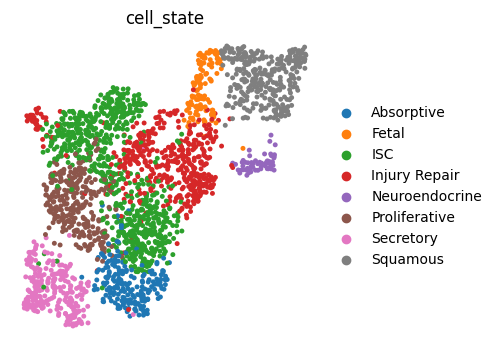

In [3]:
# Plot the patient cell states
sc.pl.umap(adata_patient, 
          color=['cell_state'], 
          frameon=False,)

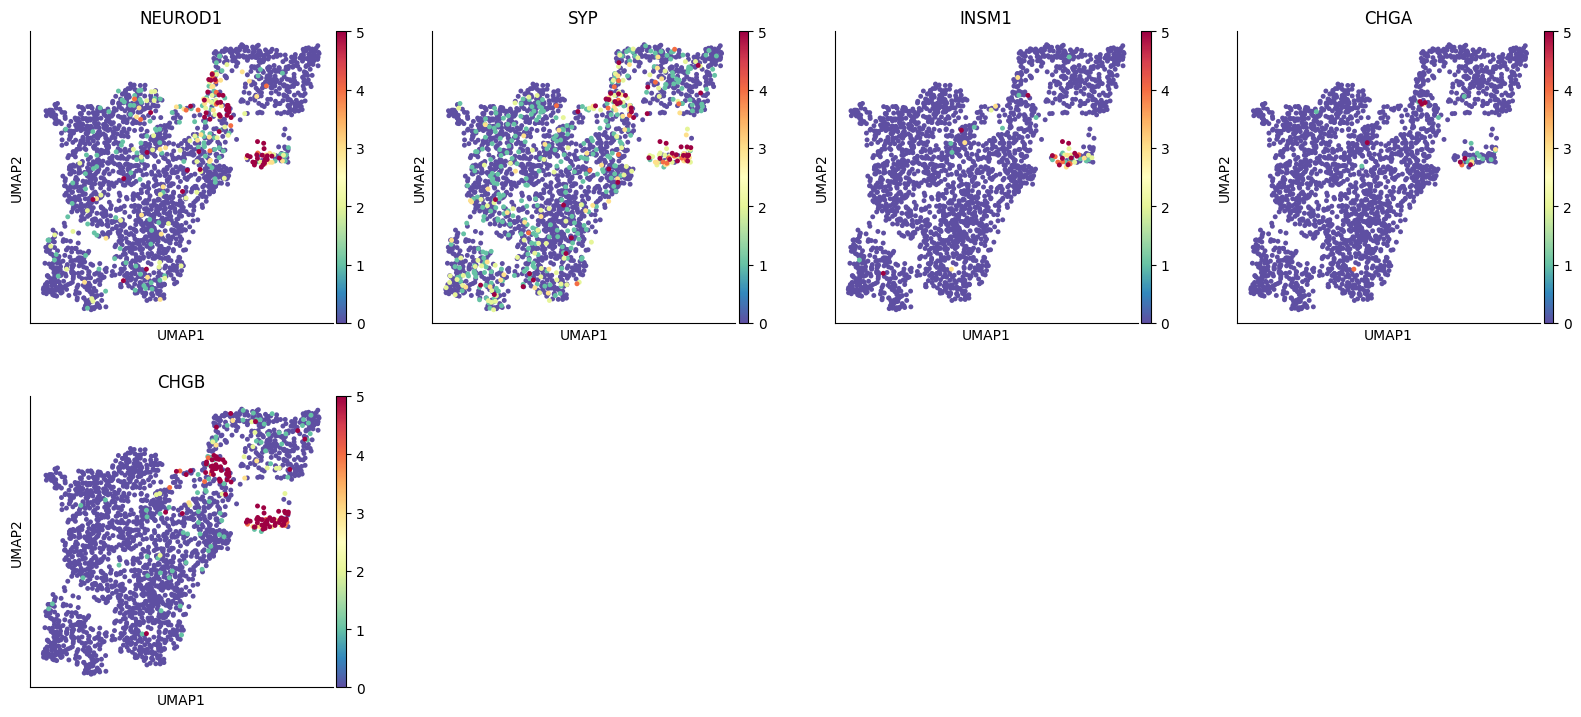

In [8]:
# Plot NE-specific gene markers
sc.pl.umap(adata_patient,
          color=['NEUROD1', 'SYP', 'INSM1', 'CHGA', 'CHGB'],
          vmax=5)

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


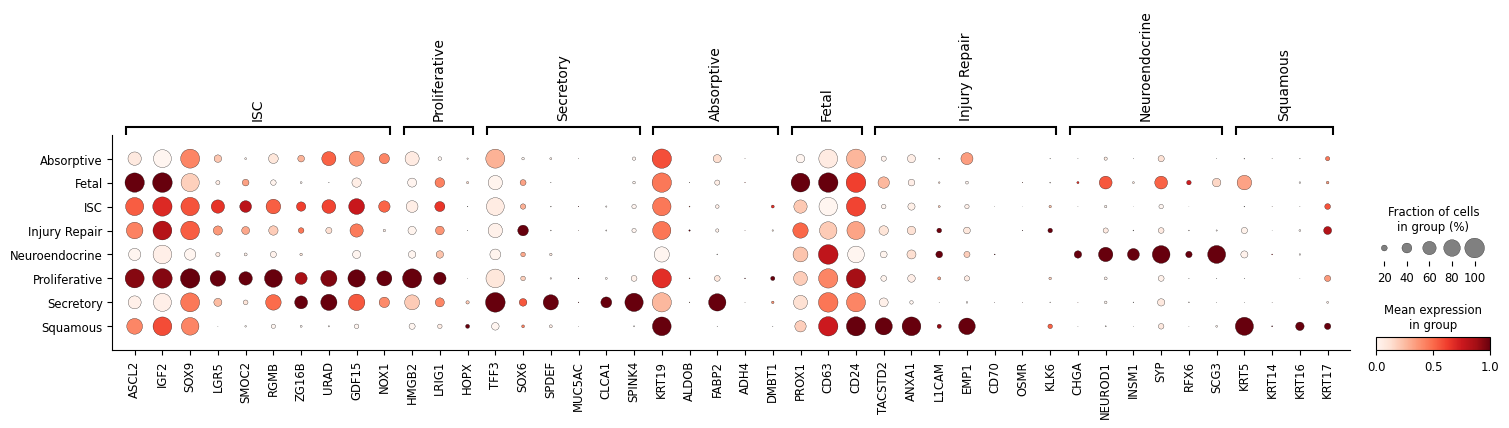

In [9]:
# Make a dotplot for the patient adata
markers = {'ISC': ['ASCL2', 'IGF2', 'SOX9', 'LGR5', 'SMOC2', 'RGMB', 'ZG16B', 'URAD', 'GDF15', 'NOX1'],
           'Proliferative': ['HMGB2', 'LRIG1', 'HOPX'],
           'Secretory': ['TFF3', 'SOX6', 'SPDEF', 'MUC5AC', 'CLCA1', 'SPINK4'],
           'Absorptive': ['KRT19', 'ALDOB', 'FABP2', 'ADH4', 'DMBT1'],
           'Fetal': ['PROX1', 'CD63', 'CD24'], 
           'Injury Repair': ['TACSTD2', 'ANXA1', 'L1CAM', 'EMP1', 'CD70', 'OSMR', 'KLK6'], 
           'Neuroendocrine': ['CHGA', 'NEUROD1', 'INSM1', 'SYP', 'RFX6', 'SCG3'],
           'Squamous': ['KRT5', 'KRT14', 'KRT16', 'KRT17']
          }
sc.pl.dotplot(adata_patient, markers, groupby=['cell_state'], standard_scale='var')#, dendrogram=True, standard_scale='var')

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


         genes  logfoldchanges         pvals     pvals_adj
0        MYH7B       50.109692  1.311085e-24  3.456544e-20
1         RBP1       61.330830  2.739762e-22  3.611555e-18
2      ASPSCR1      108.805283  5.956703e-20  5.234751e-16
3      C2ORF82      128.376083  1.105450e-19  5.828817e-16
4       STARD3       13.174450  1.105450e-19  5.828817e-16
5       OSBPL6       12.708647  1.746321e-19  7.476471e-16
6       APCDD1       32.291725  1.985105e-19  7.476471e-16
7     SERPINI1       20.055059  1.774617e-18  5.270959e-15
8       SLC1A5       32.468002  1.799372e-18  5.270959e-15
9         TRDC       26.835899  3.125468e-18  8.239984e-15
10       CCND2       26.701738  4.652878e-18  1.115168e-14
11      SEMA3C       11.149791  1.417745e-17  2.875187e-14
12       FGF19       14.009601  2.094335e-17  3.943932e-14
13       CCND1       28.833704  2.774612e-17  4.876657e-14
14       NOTUM      108.197807  4.030524e-17  6.641296e-14
15       ASCL2       26.497700  4.423577e-17  6.860187e-

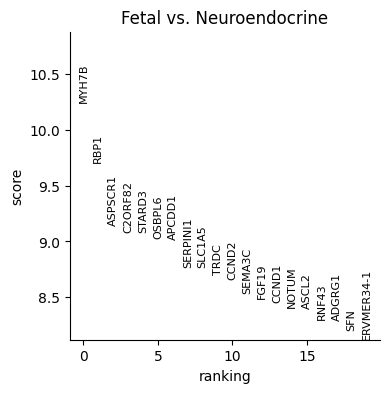

In [12]:
# Subset the data to only include cells in the 'fetal' and 'neuroendocrine' states
adata_subset = adata_patient[adata_patient.obs['cell_state'].isin(['Fetal', 'Neuroendocrine'])].copy()

# Perform differential expression analysis between 'fetal' and 'neuroendocrine'
sc.tl.rank_genes_groups(adata_subset, 'cell_state', groups=['Fetal'], reference='Neuroendocrine', method='wilcoxon')

# Get the result of the differential expression analysis
degs = adata_subset.uns['rank_genes_groups']

# Convert the DEGs into a pandas DataFrame for easier inspection
import pandas as pd
degs_df = pd.DataFrame({
    'genes': degs['names']['Fetal'],
    'logfoldchanges': degs['logfoldchanges']['Fetal'],
    'pvals': degs['pvals']['Fetal'],
    'pvals_adj': degs['pvals_adj']['Fetal']
})

# Display the top 20 differentially expressed genes
print(degs_df.head(20))

# Plot the top 20 differentially expressed genes using Scanpy's plotting function
sc.pl.rank_genes_groups(adata_subset, n_genes=20, sharey=False)

/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:419: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/forsythb/anaconda3/envs/scrna/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/

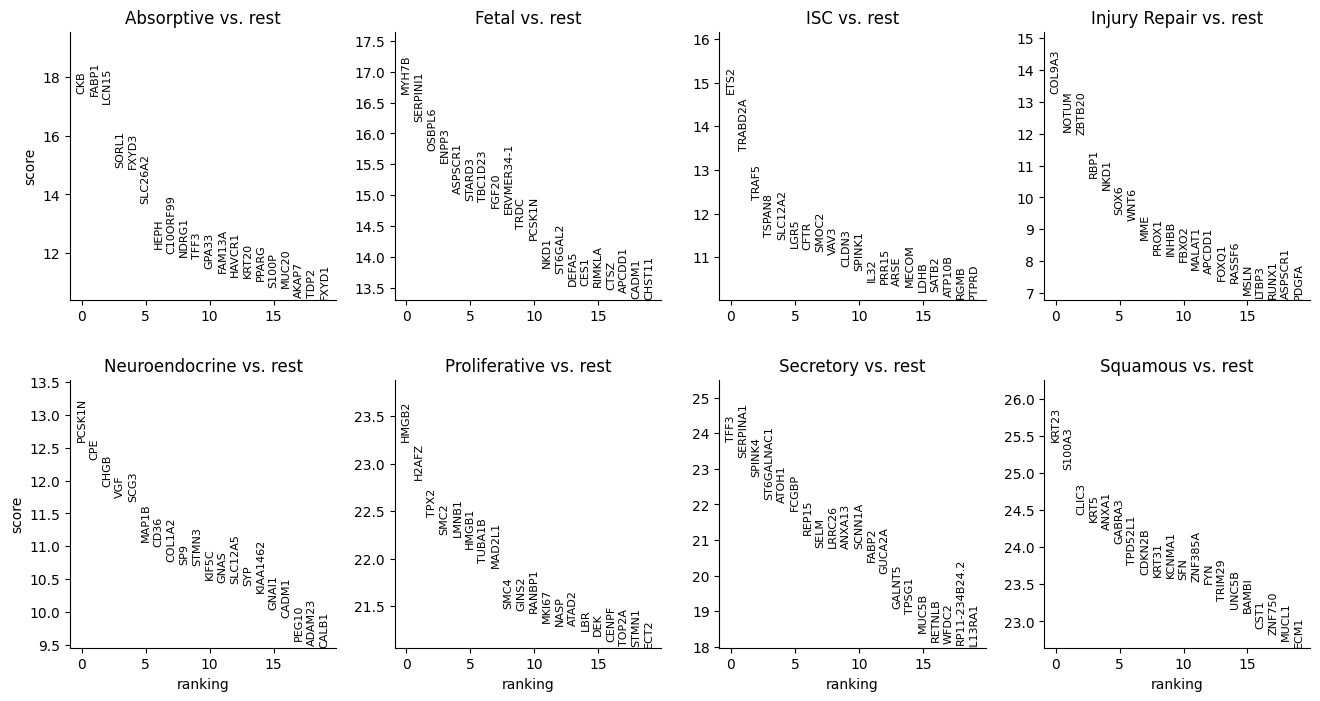

In [13]:
# Perform differential expression analysis for all cell states
sc.tl.rank_genes_groups(adata_patient, 'cell_state', method='wilcoxon')

# Plot the top DEGs for all cell states
sc.pl.rank_genes_groups(adata_patient, n_genes=20, sharey=False)
